In [1]:
#segmentação de clientes
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

In [2]:
#conectando sql com o python

conexao = ("Server=DESKTOP-OICCGK1;"
           "Driver=SQL Server;"
           "Database=ContosoRetailDW;"
           "Trusted connection=yes;")

dados = pyodbc.connect(conexao)

In [3]:
#encontrando numero de clientes por sexo
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender), 
																seg AS (
																	SELECT 
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'Younger'
																		WHEN Age > 45 AND Age < 60 THEN 'Older'
																		ELSE 'Eldery'
																		END AS 'AgeRate'
																	FROM customers)
                                                            SELECT 
                                                                CASE
                                                                WHEN Gender = 'F' THEN 'Feminino'
                                                                ELSE 'Masculino'
                                                                END AS 'Sexo',
                                                                COUNT(Gender) AS 'Quantidade'
                                                            FROM seg
                                                            WHERE Gender IS NOT NULL
                                                            GROUP BY Gender
                                                            """
clientes_por_sexo = pd.read_sql(query,dados)
display(clientes_por_sexo)



C:\Users\usu\AppData\Local\Temp\ipykernel_8560\677781544.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  clientes_por_sexo = pd.read_sql(query,dados)


,Sexo,Quantidade
0,Feminino,9133
1,Masculino,9351


In [4]:
#segmentaçao por sexo e estado civil
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender), 
																seg AS (
																	SELECT 
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'Younger'
																		WHEN Age > 45 AND Age < 60 THEN 'Older'
																		ELSE 'Eldery'
																		END AS 'AgeRate'
																	FROM customers)

													SELECT 
														CASE
															WHEN MaritalStatus = 'M' THEN 'Casado'
															ELSE 'Solteiro'
														END AS 'Estado Civil',
														CASE
															WHEN Gender = 'F' THEN 'Feminino'
															ELSE 'Masculino'
														END AS 'Sexo',
														COUNT(Gender) AS 'Quantidade'
													FROM seg
													WHERE MaritalStatus IS NOT NULL
													GROUP BY MaritalStatus,Gender"""

clientes_estado_civil = pd.read_sql(query,dados)
clientes_estado_civil = clientes_estado_civil.pivot(index="Sexo",columns="Estado Civil",values="Quantidade")
display(clientes_estado_civil)


C:\Users\usu\AppData\Local\Temp\ipykernel_8560\2316587959.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  clientes_estado_civil = pd.read_sql(query,dados)


Estado Civil,Casado,Solteiro
Sexo,,
Feminino,4745,4388
Masculino,5266,4085


In [5]:
#Classificação de idade
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender), 
																seg AS (
																	SELECT 
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'De 30 a 45'
																		WHEN Age > 45 AND Age < 60 THEN 'De 45 a 60'
																		ELSE 'Acima de 60'
																		END AS 'Idade'
																	FROM customers)

																	SELECT 
																		Idade,
																		COUNT(Idade) AS 'Quantidade'
																	FROM seg
                                                                    WHERE MaritalStatus IS NOT NULL
																	GROUP BY Idade"""

classificacao_idade = pd.read_sql(query,dados)
display(classificacao_idade)

C:\Users\usu\AppData\Local\Temp\ipykernel_8560\2121136204.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  classificacao_idade = pd.read_sql(query,dados)


,Idade,Quantidade
0,De 45 a 60,7185
1,De 30 a 45,7052
2,Acima de 60,4247


In [6]:
#calculando ticket medio geral
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											CustomerKey,
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender,CustomerKey), 
																seg AS (
																	SELECT 
																		CustomerKey,
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'De 30 a 45'
																		WHEN Age > 45 AND Age < 60 THEN 'De 45 a 60'
																		ELSE 'Acima de 60'
																		END AS 'Idade'
																	FROM customers)

																	SELECT 
																		SUM(SalesAmount) AS 'ValorTotalVendido',
																		COUNT(DISTINCT Full_Name) AS 'Qtd_clientes',
																		(SUM(SalesAmount)/COUNT(Full_Name)) AS 'TicketMedioGeral'
																	FROM FactOnlineSales AS sales
																	JOIN seg
																		ON seg.CustomerKey = sales.CustomerKey
"""

ticket_medio_geral = pd.read_sql(query,dados)
display(ticket_medio_geral)

C:\Users\usu\AppData\Local\Temp\ipykernel_8560\494535622.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ticket_medio_geral = pd.read_sql(query,dados)


,ValorTotalVendido,Qtd_clientes,TicketMedioGeral
0,2.718203e+09,18401,215.2587


In [7]:
#ticket medio por faixa etaria
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											CustomerKey,
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender,CustomerKey), 
																seg AS (
																	SELECT 
																		CustomerKey,
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'De 30 a 45'
																		WHEN Age > 45 AND Age < 60 THEN 'De 45 a 60'
																		ELSE 'Acima de 60'
																		END AS 'Idade'
																	FROM customers)

																	SELECT
																		Idade,
																		SUM(SalesAmount) AS 'ValorTotalVendido',
																		COUNT(*) AS 'Qtd_Vendas',
																		(SUM(SalesAmount)/COUNT(*)) AS 'TicketMedio'
																	FROM FactOnlineSales AS sales
																	LEFT JOIN seg 
																		ON sales.CustomerKey = seg.CustomerKey
																	GROUP BY seg.Idade"""

ticket_faixa_etaria = pd.read_sql(query,dados)
display(ticket_faixa_etaria)

C:\Users\usu\AppData\Local\Temp\ipykernel_8560\2801175025.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ticket_faixa_etaria = pd.read_sql(query,dados)


,Idade,ValorTotalVendido,Qtd_Vendas,TicketMedio
0,Acima de 60,2.198612e+09,10458235,210.2277
1,De 30 a 45,2.472925e+08,1087425,227.4110
2,De 45 a 60,2.722985e+08,1081948,251.6742


In [8]:
#ticket medio por sexo e estado civil
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											CustomerKey,
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender,CustomerKey), 
																seg AS (
																	SELECT 
																		CustomerKey,
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'De 30 a 45'
																		WHEN Age > 45 AND Age < 60 THEN 'De 45 a 60'
																		ELSE 'Acima de 60'
																		END AS 'Idade'
																	FROM customers)

													SELECT
													CASE
														WHEN MaritalStatus = 'M' THEN 'Casado(a)'
														ELSE 'Solteiro(a)'
													END AS 'EstadoCivil',
													CASE
														WHEN Gender = 'F' THEN 'Feminino'
														ELSE 'Masculino'
													END AS 'Sexo',
														SUM(SalesAmount) AS 'Vendas',
														COUNT(*) AS 'QtdVendas',
														SUM(SalesAmount)/COUNT(*)
													FROM seg
													LEFT JOIN FactOnlineSales AS sales
														ON seg.CustomerKey = sales.CustomerKey
													WHERE MaritalStatus IS NOT NULL
													GROUP BY MaritalStatus,Gender"""

ticket_sexo = pd.read_sql(query,dados)
display(ticket_sexo)


C:\Users\usu\AppData\Local\Temp\ipykernel_8560\124029139.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ticket_sexo = pd.read_sql(query,dados)


,EstadoCivil,Sexo,Vendas,QtdVendas,
0,Casado(a),Feminino,1.840720e+08,729374,252.3698
1,Solteiro(a),Feminino,1.548274e+08,665275,232.7269
2,Casado(a),Masculino,2.012499e+08,797912,252.2206
3,Solteiro(a),Masculino,1.456043e+08,639632,227.6376


In [9]:
#ticket medio ao longo dos anos
query = """WITH old AS (SELECT
				MAX(FullDateLabel) AS 'oldestdate' 
				FROM DimDate), customers AS (
										SELECT 
											CustomerKey,
											FirstName,
											LastName,
											MaritalStatus,
											Gender,
											DATEDIFF(YEAR ,BirthDate, (SELECT oldestdate FROM old)) AS 'Age'
										FROM DimCustomer
										GROUP BY FirstName,LastName,MaritalStatus,BirthDate,Gender,CustomerKey), 
																seg AS (
																	SELECT 
																		CustomerKey,
																		CONCAT_WS(' ',FirstName,LastName) AS 'Full_Name',
																		MaritalStatus,
																		Gender,
																		Age,
																		CASE
																		WHEN Age > 30 AND Age < 45 THEN 'De 30 a 45'
																		WHEN Age > 45 AND Age < 60 THEN 'De 45 a 60'
																		ELSE 'Acima de 60'
																		END AS 'Idade'
																	FROM customers)

																	SELECT 
																		CalendarYear,
																		SUM(SalesAmount) AS 'ValorTotalVendido',
																		COUNT(DISTINCT Full_Name) AS 'Qtd_clientes',
																		(SUM(SalesAmount)/COUNT(Full_Name)) AS 'TicketMedioGeral'
																	FROM FactOnlineSales AS sales
																	JOIN seg
																		ON seg.CustomerKey = sales.CustomerKey
																	JOIN DimDate
																		ON sales.DateKey = DimDate.Datekey
																	GROUP BY CalendarYear
																	ORDER BY CalendarYear"""

ticket_anos = pd.read_sql(query,dados)
display(ticket_anos)

C:\Users\usu\AppData\Local\Temp\ipykernel_8560\1423111857.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ticket_anos = pd.read_sql(query,dados)


,CalendarYear,ValorTotalVendido,Qtd_clientes,TicketMedioGeral
0,2007,1.010803e+09,18400,252.6992
1,2008,8.496712e+08,18400,234.2936
2,2009,8.577280e+08,17507,171.5092


C:\Users\usu\AppData\Local\Temp\ipykernel_8560\4256427361.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["B"].set_xticklabels(clientes_estado_civil.index,fontweight="bold")


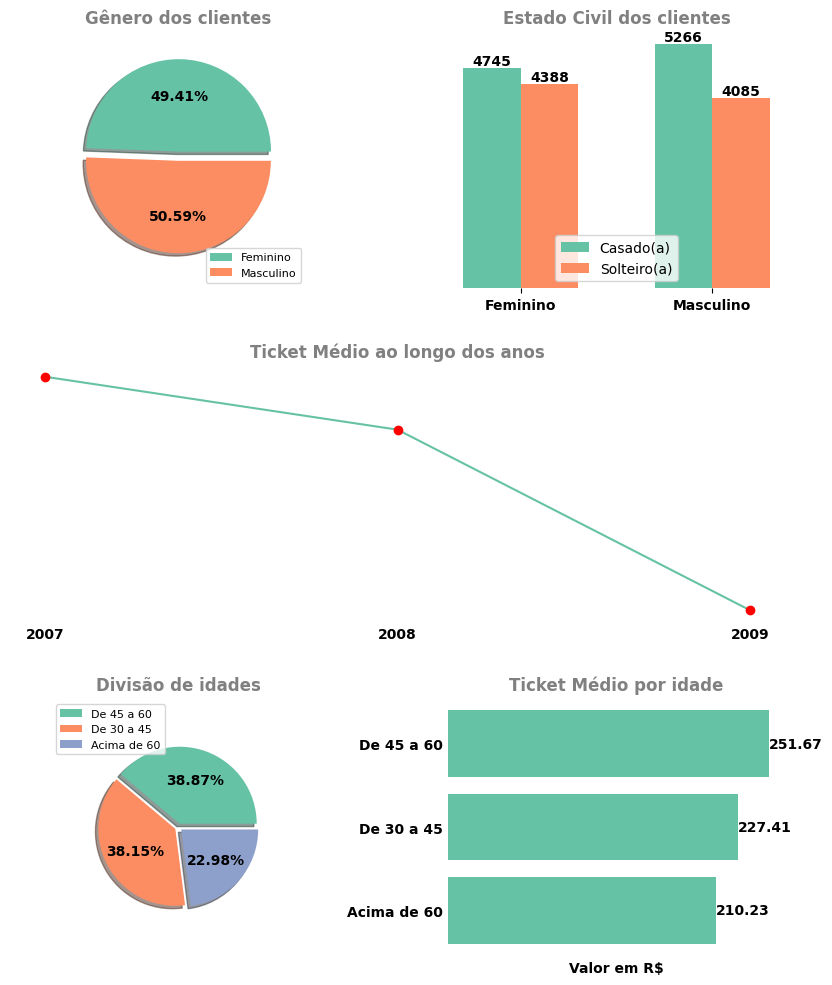

In [10]:
cores = plt.get_cmap("Set2").colors
ciclo = cycler(color=cores)
plt.rc("axes",prop_cycle=ciclo)

def format(valor):
    return "R$ {:,.2f}".format(valor)

mosaico = 'AB;CC;DE'
espacamento = {"wspace":0.3,"hspace":0.3}
fig = plt.figure(figsize=(10,12))
axs = fig.subplot_mosaic(mosaico,gridspec_kw=espacamento)

#clientes por sexo
destaque = [0.08,0.01]
axs['A'].pie(clientes_por_sexo["Quantidade"],autopct='%.2f%%',textprops={"fontweight":"bold"},shadow=True,explode=destaque,labels=None,radius=0.9)
axs['A'].set_title("Gênero dos clientes",fontweight="bold",color="gray")
axs['A'].legend(labels=clientes_por_sexo["Sexo"],loc="lower right",fontsize=8)

#clientes por estado civil
x = np.arange(len(clientes_estado_civil.index))
largura = 0.3
            
barras_casado = axs["B"].bar(x - largura/2, clientes_estado_civil["Casado"],largura,label="Casado(a)")
barras_solteiro = axs["B"].bar(x + largura/2, clientes_estado_civil["Solteiro"],largura,label="Solteiro(a)")

axs["B"].bar_label(barras_casado,fontweight="bold")
axs["B"].bar_label(barras_solteiro,fontweight="bold")

axs["B"].set_xticklabels(clientes_estado_civil.index,fontweight="bold")
axs["B"].set_xticks(x)
axs["B"].set_yticks([])
axs["B"].tick_params("y",length=0)
axs["B"].legend(loc="lower center")
axs["B"].set_title("Estado Civil dos clientes",color="gray",fontweight="bold")

axs["B"].spines['top'].set_visible(False)
axs["B"].spines['right'].set_visible(False)
axs["B"].spines['left'].set_visible(False)
axs["B"].spines['bottom'].set_visible(False)

#ticket medio ao longo dos anos
axs["C"].plot(ticket_anos["CalendarYear"],ticket_anos["TicketMedioGeral"])
axs["C"].scatter(ticket_anos["CalendarYear"],ticket_anos["TicketMedioGeral"],color="red",zorder=2)

axs["C"].set_xticks(ticket_anos["CalendarYear"])
axs["C"].set_xticklabels(ticket_anos["CalendarYear"],fontweight="bold")
axs["C"].set_yticks([])
axs["C"].set_title("Ticket Médio ao longo dos anos",color="gray",fontweight="bold")
axs["C"].tick_params("y",length=0)
axs["C"].tick_params("x",length=0)

axs["C"].spines['top'].set_visible(False)
axs["C"].spines['right'].set_visible(False)
axs["C"].spines['left'].set_visible(False)
axs["C"].spines['bottom'].set_visible(False)

#classificaçao de idade
destaques = [0.035,0.035,0.035]
axs["D"].pie(classificacao_idade["Quantidade"],explode=destaques,autopct='%.2f%%',shadow=destaques,labels=None,radius=0.75,textprops={"fontweight":"bold","fontsize":10})
axs["D"].set_title("Divisão de idades",fontweight="bold",color="gray")
axs["D"].legend(labels=classificacao_idade["Idade"],loc="upper left",fontsize=8)

#ticket medio por faixa etaria
barras = axs["E"].barh(ticket_faixa_etaria["Idade"],ticket_faixa_etaria["TicketMedio"].round(2))
axs["E"].bar_label(barras,fontweight="bold")
axs["E"].set_title("Ticket Médio por idade",color="gray",fontweight="bold")

axs["E"].set_yticks(ticket_faixa_etaria["Idade"])
axs["E"].set_xticks([])

axs["E"].set_yticklabels(ticket_faixa_etaria["Idade"],fontweight="bold")
axs["E"].set_xlabel("Valor em R$",fontsize=10,fontweight="bold")

axs["E"].spines['top'].set_visible(False)
axs["E"].spines['right'].set_visible(False)
axs["E"].spines['left'].set_visible(False)
axs["E"].spines['bottom'].set_visible(False)

axs["E"].tick_params("y",length=0)


plt.show()
